# Práctica 2B: Análisis de componentes principales (PCA)

**Realizado por: Eduardo Alanís García**



## Instrucciones

El algoritmo PCA Se puede usar como un paso en el preprocesado de los datos. Si se va a aplicar un algoritmo de clustering, se aconseja primero disminuir la dimensión de los datos. Algoritmos como k-means tienen problemas de desempeño cuando se usan muchas dimensiones. Además, aplicar PCA ayuda a separar los datos de manera automática.

Leer el conjunto MNIST.
```python
X, y = fetch_openml("mnist_784", return_X_y=True, as_frame=False)
```

1. Usar sólo las imágenes con ceros o unos. Reescalar los datos usando [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html "StandardScaler"). Aplicar PCA para reducir la dimensión a dos y graficar los puntos, el color de los puntos debe indicar la clase a la que pertenece.
   - Aplicar k-means (con `random_state=1`) para separar los dos clusters antes y depués de aplicar PCA.
   - Comparar la calidad de los clusters con la métrica [rand_score](https://scikit-learn.org/stable/modules/clustering.html#rand-index "rand_score") de sklearn.

2. Repetir lo mismo pero reducir la dimensión a 50.
   - Dentro de un ciclo `for` aumentar el número de clases de 2 a 10.
   - Aplicar `StandardScaler`.
   - Aplciar kmeans (con `random_state=1`) con y sin PCA.
   - Compararla calidad de los clusters con la métrica rand_score.

3. Contesta la evaluación de esta práctica en el Aula Virtual.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import rand_score


### Lee el conjunto de datos MNIST

In [9]:
X, y = fetch_openml("mnist_784", return_X_y=True, as_frame=False)

print(f"Datos de X: {X}")
print(f"Datos de y: {y}")


Datos de X: [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
Datos de y: ['5' '0' '4' ... '4' '5' '6']


In [10]:
print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")

Dimensiones de X: (70000, 784)
Dimensiones de y: (70000,)


In [11]:
y = y.astype(int)
print(f"Unicos de y: {np.unique(y)}")

Unicos de y: [0 1 2 3 4 5 6 7 8 9]


### Usa sólo las imágenes con ceros o unos y escala los datos


In [13]:
#Imagenes 0 y 1
mascara_01 = (y == 0) | (y == 1)

X_01 = X[mascara_01]
y_01 = y[mascara_01]

# Escalar
escalador_01 = StandardScaler()
X_01_escalado = escalador_01.fit_transform(X_01)

clases_01, cantidades_01 = np.unique(y_01, return_counts=True)

print(f"Dimensiones de X_01: {X_01.shape}")
print(f"Clases y número de imágenes: {list(zip(clases_01, cantidades_01))}")
print(f"Clases: {clases_01}")
print(f"Número de imágenes: {cantidades_01}")


Dimensiones de X_01: (14780, 784)
Clases y número de imágenes: [(np.int64(0), np.int64(6903)), (np.int64(1), np.int64(7877))]
Clases: [0 1]
Número de imágenes: [6903 7877]


## Aplica PCA para reducir la dimensión a dos y grafica los puntos

El color indica si la clase real de la imagen es 0 o 1

Dimensiones después de PCA: (14780, 2)
Varianza explicada por las dos componentes: 0.23


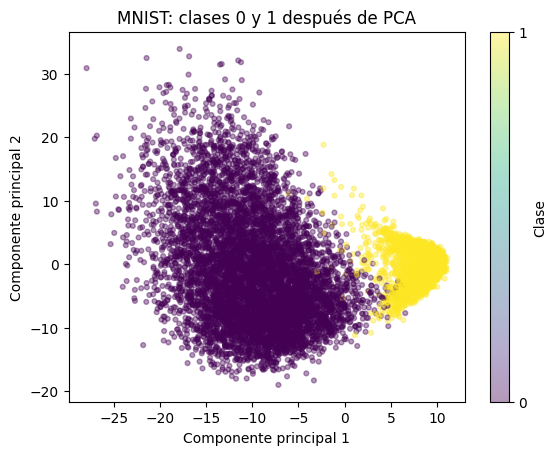

In [17]:
pca_2 = PCA(n_components=2, random_state=1)
X_01_pca_2 = pca_2.fit_transform(X_01_escalado)

print(f"Dimensiones después de PCA: {X_01_pca_2.shape}")
print(f"Varianza explicada por las dos componentes: {pca_2.explained_variance_ratio_.sum():.2f}")

puntos = plt.scatter(
    X_01_pca_2[:, 0],
    X_01_pca_2[:, 1],
    c=y_01,
    cmap="viridis",
    alpha=0.4,
    s=12
)
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title("MNIST: clases 0 y 1 después de PCA")
plt.colorbar(puntos, ticks=[0, 1], label="Clase")
plt.show()


## Aplica K-means antes y después de PCA con dos componentes

Se ajustan dos modelos con dos clusters y random_state=1: uno recibe las características escaladas originales y el otro recibe la representación de dos componentes. rand_score compara cada resultado con las clases reales.


In [21]:
kmeans_01_original = KMeans(n_clusters=2, n_init="auto", random_state=1)
clusters_01_original = kmeans_01_original.fit_predict(X_01_escalado)
rand_01_original = rand_score(y_01, clusters_01_original)

kmeans_01_pca_2 = KMeans(n_clusters=2, n_init="auto", random_state=1)
clusters_01_pca_2 = kmeans_01_pca_2.fit_predict(X_01_pca_2)
rand_01_pca_2 = rand_score(y_01, clusters_01_pca_2)

print(f"rand_score sin PCA (784 características): {rand_01_original:.4f}")
print(f"rand_score con PCA (2 componentes):       {rand_01_pca_2:.4f}")


rand_score sin PCA (784 características): 0.9792
rand_score con PCA (2 componentes):       0.9737


## Comparar la calidad de los clusters con la métrica rand_score de sklearn

In [20]:
if rand_01_pca_2 > rand_01_original:
    print("Para estas dos clases, la representación de dos componentes obtuvo un rand_score mayor.")
elif rand_01_pca_2 < rand_01_original:
    print("Para estas dos clases, la representación original obtuvo un rand_score mayor.")
else:
    print("Las dos representaciones obtuvieron el mismo rand_score.")


Para estas dos clases, la representación original obtuvo un rand_score mayor.


El rand_score más alto representa más acuerdos entre pares de imágenes y las clases reales


## 5. Repite la comparación usando 50 componentes

Ahora se conservan 50 componentes principales. Se compara el resultado con los píxeles escalados originales y con la reducción a dos componentes. La varianza explicada acumulada ayuda a describir cuánta variación conserva esta representación.


In [23]:
pca_50 = PCA(n_components=50, random_state=1)
X_01_pca_50 = pca_50.fit_transform(X_01_escalado)

print(f"Dimensiones después de PCA: {X_01_pca_50.shape}")
print(f"Varianza explicada por las 50 componentes: {pca_50.explained_variance_ratio_.sum():.4f}")

kmeans_01_pca_50 = KMeans(n_clusters=2, n_init="auto", random_state=1)
clusters_01_pca_50 = kmeans_01_pca_50.fit_predict(X_01_pca_50)
rand_01_pca_50 = rand_score(y_01, clusters_01_pca_50)

representaciones_01 = [
    "Original (784 características)",
    "PCA (2 componentes)",
    "PCA (50 componentes)"
]
rand_scores_01 = [
    rand_01_original,
    rand_01_pca_2,
    rand_01_pca_50
]

for representacion, score in zip(representaciones_01, rand_scores_01):
    print(f"{representacion}: rand_score = {score:.4f}")


Dimensiones después de PCA: (14780, 50)
Varianza explicada por las 50 componentes: 0.6656
Original (784 características): rand_score = 0.9792
PCA (2 componentes): rand_score = 0.9737
PCA (50 componentes): rand_score = 0.9790


In [24]:
if rand_01_pca_50 > rand_01_original:
    print("Con 50 componentes, PCA obtuvo un rand_score mayor que la representación original.")
elif rand_01_pca_50 < rand_01_original:
    print("Con 50 componentes, la representación original obtuvo un rand_score mayor que PCA.")
else:
    print("Con 50 componentes, ambas representaciones obtuvieron el mismo rand_score.")


Con 50 componentes, la representación original obtuvo un rand_score mayor que PCA.


## Aumenta el número de clases de 2 a 10

Para cada valor se usan las clases desde 0 hasta k - 1. Se escalan las imágenes de ese subconjunto y se ajustan dos modelos K-means con random_state=1: uno con las 784 características y otro con PCA de 50 componentes. El mismo subconjunto se usa en ambas comparaciones. El ciclo puede tardar porque vuelve a ajustar PCA y K-means para cada k.


In [25]:
numero_clases = []
rand_sin_pca = []
rand_con_pca = []

for k in range(2, 11):
    mascara = y < k
    X_k = X[mascara]
    y_k = y[mascara]

    escalador_k = StandardScaler()
    X_k_escalado = escalador_k.fit_transform(X_k)

    pca_k = PCA(n_components=50, random_state=1)
    X_k_pca_50 = pca_k.fit_transform(X_k_escalado)

    kmeans_original = KMeans(n_clusters=k, n_init="auto", random_state=1)
    clusters_original = kmeans_original.fit_predict(X_k_escalado)
    score_original = rand_score(y_k, clusters_original)

    kmeans_pca = KMeans(n_clusters=k, n_init="auto", random_state=1)
    clusters_pca = kmeans_pca.fit_predict(X_k_pca_50)
    score_pca = rand_score(y_k, clusters_pca)

    numero_clases.append(k)
    rand_sin_pca.append(score_original)
    rand_con_pca.append(score_pca)

    print(
        f"Clases: {k} | "
        f"sin PCA: {score_original:.4f} | "
        f"con PCA (50): {score_pca:.4f}"
    )


Clases: 2 | sin PCA: 0.9792 | con PCA (50): 0.9790
Clases: 3 | sin PCA: 0.9059 | con PCA (50): 0.9055
Clases: 4 | sin PCA: 0.8648 | con PCA (50): 0.8646
Clases: 5 | sin PCA: 0.8403 | con PCA (50): 0.8588
Clases: 6 | sin PCA: 0.8569 | con PCA (50): 0.8562
Clases: 7 | sin PCA: 0.8317 | con PCA (50): 0.8515
Clases: 8 | sin PCA: 0.8546 | con PCA (50): 0.8753
Clases: 9 | sin PCA: 0.8444 | con PCA (50): 0.8579
Clases: 10 | sin PCA: 0.8515 | con PCA (50): 0.8663


## Compara los resultados

La gráfica presenta el rand_score para cada número de clases. Para cada k, ambas líneas corresponden a los mismos ejemplos y al mismo número de clusters.


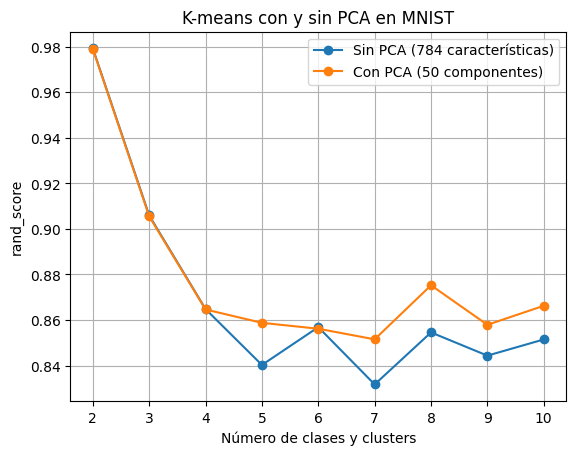

In [26]:
plt.plot(numero_clases, rand_sin_pca, "-o", label="Sin PCA (784 características)")
plt.plot(numero_clases, rand_con_pca, "-o", label="Con PCA (50 componentes)")
plt.xticks(numero_clases)
plt.xlabel("Número de clases y clusters")
plt.ylabel("rand_score")
plt.title("K-means con y sin PCA en MNIST")
plt.legend()
plt.grid(True)
plt.show()


In [27]:
for k, score_original, score_pca in zip(numero_clases, rand_sin_pca, rand_con_pca):
    if score_pca > score_original:
        print(f"Con {k} clases, PCA obtuvo el rand_score mayor.")
    elif score_pca < score_original:
        print(f"Con {k} clases, los datos originales obtuvieron el rand_score mayor.")
    else:
        print(f"Con {k} clases, las dos representaciones obtuvieron el mismo rand_score.")


Con 2 clases, los datos originales obtuvieron el rand_score mayor.
Con 3 clases, los datos originales obtuvieron el rand_score mayor.
Con 4 clases, los datos originales obtuvieron el rand_score mayor.
Con 5 clases, PCA obtuvo el rand_score mayor.
Con 6 clases, los datos originales obtuvieron el rand_score mayor.
Con 7 clases, PCA obtuvo el rand_score mayor.
Con 8 clases, PCA obtuvo el rand_score mayor.
Con 9 clases, PCA obtuvo el rand_score mayor.
Con 10 clases, PCA obtuvo el rand_score mayor.


## Contesta la evaluación de esta práctica en el Aula Virtual